In [27]:
import os
import math
import random
import zipfile
import urllib.request
import requests

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader


SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [28]:
# =========================================================
# MrTransformer configuration
# =========================================================

MAX_LEN = 50

HIDDEN_DIM = 64

NUM_HEADS = 2

NUM_LAYERS = 2

NUM_PREFERENCES = 3

DROPOUT = 0.2

BATCH_SIZE = 128

LR = 1e-3

WEIGHT_DECAY = 1e-4

EPOCHS_PRETRAIN = 20

EPOCHS_FINETUNE = 20


# Loss weights
COVERAGE_WEIGHT = 0.1

SSL_RECOMBINATION_WEIGHT = 0.1

SSL_COMMON_WEIGHT = 0.1


print("MAX_LEN:", MAX_LEN)
print("HIDDEN_DIM:", HIDDEN_DIM)
print("HEADS:", NUM_HEADS)
print("LAYERS:", NUM_LAYERS)
print("K:", NUM_PREFERENCES)

MAX_LEN: 50
HIDDEN_DIM: 64
HEADS: 2
LAYERS: 2
K: 3


In [29]:
DATA_URL = (
    "https://files.grouplens.org/"
    "datasets/movielens/ml-100k.zip"
)

ZIP_PATH = "/content/ml-100k.zip"
DATA_DIR = "/content/ml-100k"


if not os.path.exists(DATA_DIR):

    print("Downloading ML-100K...")

    urllib.request.urlretrieve(
        DATA_URL,
        ZIP_PATH
    )

    print("Extracting...")

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as z:

        z.extractall("/content")


print(
    "Dataset exists:",
    os.path.exists(DATA_DIR)
)

Dataset exists: True


In [30]:
DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"

DATA_DIR = "./data"
ZIP_PATH = os.path.join(DATA_DIR, "ml-100k.zip")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(ZIP_PATH):
    print("Downloading MovieLens-100K...")

    response = requests.get(DATA_URL)
    response.raise_for_status()

    with open(ZIP_PATH, "wb") as f:
        f.write(response.content)

if not os.path.exists(os.path.join(DATA_DIR, "ml-100k")):
    print("Extracting...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

print("Dataset ready.")

Dataset ready.


In [31]:
ratings_path = "./data/ml-100k/u.data"

ratings = pd.read_csv(
    ratings_path,
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [32]:
ratings_path = "./data/ml-100k/u.data"

ratings = pd.read_csv(
    ratings_path,
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

# فقط این دو خط رو اضافه کن:
df = ratings.rename(columns={
    "user_id": "user",
    "item_id": "item"
})

df = df.sort_values(
    ["user", "timestamp"]
).reset_index(drop=True)

In [33]:
df = df.sort_values(
    ["user", "timestamp"]
).reset_index(drop=True)


user_sequences_raw = {}

for user, group in df.groupby("user"):

    sequence = group[
        "item"
    ].tolist()

    # At least 5 interactions
    if len(sequence) >= 5:

        user_sequences_raw[user] = sequence


print(
    "Users after filtering:",
    len(user_sequences_raw)
)

lengths = [
    len(x)
    for x in user_sequences_raw.values()
]

print(
    "Average sequence length:",
    np.mean(lengths)
)

print(
    "Max sequence length:",
    np.max(lengths)
)

Users after filtering: 943
Average sequence length: 106.04453870625663
Max sequence length: 737


In [ ]:
df = df.sort_values(
    ["user", "timestamp"]
).reset_index(drop=True)


user_sequences_raw = {}

for user, group in df.groupby("user"):

    sequence = group[
        "item"
    ].tolist()

    # At least 5 interactions
    if len(sequence) >= 5:

        user_sequences_raw[user] = sequence


print(
    "Users after filtering:",
    len(user_sequences_raw)
)

lengths = [
    len(x)
    for x in user_sequences_raw.values()
]

print(
    "Average sequence length:",
    np.mean(lengths)
)

print(
    "Max sequence length:",
    np.max(lengths)
)

Users after filtering: 943
Average sequence length: 106.04453870625663
Max sequence length: 737


In [35]:
all_items = sorted(
    set(
        item
        for seq in user_sequences_raw.values()
        for item in seq
    )
)


item2id = {
    item: idx + 1
    for idx, item in enumerate(all_items)
}


id2item = {
    idx: item
    for item, idx in item2id.items()
}


NUM_ITEMS = len(item2id)


print(
    "NUM_ITEMS:",
    NUM_ITEMS
)

NUM_ITEMS: 1682


In [36]:
user_sequences = {}


for user, seq in user_sequences_raw.items():

    encoded = [
        item2id[item]
        for item in seq
    ]

    user_sequences[user] = encoded


print(
    list(user_sequences.items())[:2]
)

[(1, [168, 172, 165, 156, 196, 166, 187, 14, 250, 127, 117, 181, 109, 1, 246, 248, 257, 50, 253, 249, 262, 224, 93, 124, 19, 137, 123, 146, 7, 235, 15, 260, 264, 24, 245, 126, 237, 25, 13, 121, 251, 236, 240, 118, 130, 47, 65, 190, 31, 114, 39, 28, 52, 238, 183, 69, 199, 11, 161, 95, 60, 179, 83, 64, 98, 22, 135, 202, 163, 26, 89, 8, 214, 182, 48, 160, 175, 99, 192, 128, 180, 185, 143, 68, 55, 204, 56, 96, 81, 151, 79, 70, 212, 23, 84, 184, 197, 191, 94, 134, 145, 207, 186, 97, 188, 159, 85, 36, 144, 17, 174, 252, 105, 148, 108, 147, 243, 220, 106, 122, 104, 107, 247, 120, 45, 268, 267, 259, 261, 263, 10, 150, 234, 92, 71, 42, 176, 91, 193, 217, 177, 216, 194, 73, 59, 133, 41, 195, 218, 170, 213, 157, 223, 227, 27, 80, 231, 67, 200, 119, 4, 215, 164, 2, 206, 77, 53, 136, 40, 46, 153, 269, 254, 115, 173, 211, 229, 155, 203, 62, 90, 219, 167, 61, 230, 162, 35, 265, 112, 57, 49, 30, 233, 131, 82, 152, 141, 72, 33, 158, 198, 113, 225, 21, 149, 88, 103, 239, 110, 101, 34, 43, 29, 132, 210, 

In [37]:
user_timestamps_raw = {}
for user, group in df.groupby("user"):
    ts_seq = group["timestamp"].tolist()
    seq = group["item"].tolist()
    if len(seq) >= 5:
        user_timestamps_raw[user] = ts_seq

In [38]:
train_sequences = {}

val_targets = {}

test_targets = {}


for user, seq in user_sequences.items():

    if len(seq) < 5:
        continue

    train_sequences[user] = seq[:-2]

    val_targets[user] = seq[-2]

    test_targets[user] = seq[-1]


print(
    "Train users:",
    len(train_sequences)
)

print(
    "Validation users:",
    len(val_targets)
)

print(
    "Test users:",
    len(test_targets)
)

Train users: 943
Validation users: 943
Test users: 943


In [ ]:
train_timestamps = {}
for user, seq in user_sequences.items():
    if len(seq) < 5:
        continue
    train_timestamps[user] = user_timestamps_raw[user][:-2]

In [40]:
class SequentialDataset(Dataset):

    def __init__(self, sequences, timestamps, max_len=50):
        self.samples = []
        self.max_len = max_len

        for user, seq in sequences.items():
            ts_seq = timestamps[user]

            for i in range(1, len(seq)):
                history = seq[:i][-max_len:]
                target = seq[i]
                last_ts = ts_seq[i - 1]

                self.samples.append((history, target, last_ts))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        history, target, last_ts = self.samples[index]
        return {
            "sequence": history,
            "target": target,
            "last_ts": last_ts
        }

In [41]:
def collate_fn(batch):
    batch_size = len(batch)

    sequences = torch.zeros(batch_size, MAX_LEN, dtype=torch.long)
    targets = torch.zeros(batch_size, dtype=torch.long)
    hours = torch.zeros(batch_size, dtype=torch.long)

    for i, sample in enumerate(batch):
        seq = torch.tensor(sample["sequence"], dtype=torch.long)
        seq = seq[-MAX_LEN:]

        sequences[i, -len(seq):] = seq
        targets[i] = sample["target"]
        hours[i] = (sample["last_ts"] // 3600) % 24

    return {
        "sequence": sequences,
        "target": targets,
        "hour": hours
    }

In [42]:
train_dataset = SequentialDataset(train_sequences, train_timestamps, MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)


print(
    "Training samples:",
    len(train_dataset)
)

Training samples: 97171


In [43]:
class TransformerBlock(nn.Module):

    def __init__(
        self,
        hidden_dim,
        num_heads,
        dropout
    ):

        super().__init__()


        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )


        self.norm1 = nn.LayerNorm(
            hidden_dim
        )


        self.ffn = nn.Sequential(

            nn.Linear(
                hidden_dim,
                hidden_dim * 4
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                hidden_dim * 4,
                hidden_dim
            ),

            nn.Dropout(dropout)
        )


        self.norm2 = nn.LayerNorm(
            hidden_dim
        )


    def forward(
        self,
        x,
        attn_mask=None,
        key_padding_mask=None
    ):

        attn_output, attention = \
            self.attention(
                x,
                x,
                x,
                attn_mask=attn_mask,
                key_padding_mask=key_padding_mask,
                need_weights=True,
                average_attn_weights=False
            )


        x = self.norm1(
            x + attn_output
        )


        x = self.norm2(
            x + self.ffn(x)
        )


        return x, attention

In [44]:
class DynamicPreferenceWeighting(nn.Module):

    def __init__(self, hidden_dim):
        super().__init__()
        self.context_projection = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.preference_projection = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.temperature = nn.Parameter(torch.tensor(1.0))

    def forward(self, preferences, context):
        # preferences: [B, K, D]   context: [B, D]
        context = self.context_projection(context)
        preferences_proj = self.preference_projection(preferences)

        context = F.normalize(context, dim=-1)
        preferences_proj = F.normalize(preferences_proj, dim=-1)

        scores = torch.sum(preferences_proj * context.unsqueeze(1), dim=-1)  # [B, K]
        temperature = self.temperature.abs() + 1e-6
        weights = F.softmax(scores / temperature, dim=-1)

        weighted_preferences = preferences * weights.unsqueeze(-1)
        representation = weighted_preferences.sum(dim=1)

        return representation, weights

In [ ]:
class MrTransformer(nn.Module):

    def __init__(
        self,
        num_items,
        max_len,
        hidden_dim,
        num_heads,
        num_layers,
        num_preferences,
        dropout
    ):

        super().__init__()


        self.num_items = num_items

        self.max_len = max_len

        self.hidden_dim = hidden_dim

        self.num_preferences = \
            num_preferences


        # -------------------------------------------------
        # Item embedding
        # -------------------------------------------------

        self.item_embedding = nn.Embedding(
            num_items + 1,
            hidden_dim,
            padding_idx=0
        )


        # -------------------------------------------------
        # Position embedding
        # -------------------------------------------------

        self.position_embedding = nn.Embedding(
            max_len + num_preferences,
            hidden_dim
        )


        # -------------------------------------------------
        # Preference tokens
        # -------------------------------------------------

        self.preference_tokens = nn.Parameter(
            torch.randn(
                1,
                num_preferences,
                hidden_dim
            ) * 0.02
        )


        self.dropout = nn.Dropout(
            dropout
        )
        self.dpw = DynamicPreferenceWeighting(hidden_dim)

        # -------------------------------------------------
        # Transformer
        # -------------------------------------------------

        self.layers = nn.ModuleList([

            TransformerBlock(
                hidden_dim,
                num_heads,
                dropout
            )

            for _ in range(num_layers)
        ])


        # -------------------------------------------------
        # Output
        # -------------------------------------------------

        self.output_projection = nn.Linear(
            hidden_dim,
            num_items + 1
        )


        # Weight tying
        self.output_projection.weight = \
            self.item_embedding.weight


    # =====================================================
    # Attention mask
    # =====================================================

    def create_attention_mask(
        self,
        total_len,
        device
    ):

        K = self.num_preferences

        mask = torch.zeros(
            total_len,
            total_len,
            dtype=torch.bool,
            device=device
        )


        # Item positions cannot attend
        # to future items.

        for i in range(K, total_len):

            for j in range(K, total_len):

                if j > i:

                    mask[i, j] = True


        return mask


    # =====================================================
    # Preference coverage
    # =====================================================

    def coverage_loss(
        self,
        attention,
        sequence
    ):

        K = self.num_preferences


        # attention:
        #
        # [B, H, T, T]

        preference_attention = \
            attention[
                :,
                :,
                :K,
                K:
            ]


        # Average heads

        preference_attention = \
            preference_attention.mean(dim=1)


        # [B, K, L]


        valid_mask = (
            sequence != 0
        ).float()


        preference_attention = \
            preference_attention * \
            valid_mask.unsqueeze(1)


        # Normalize

        denominator = \
            preference_attention.sum(
                dim=-1,
                keepdim=True
            ) + 1e-8


        preference_attention = \
            preference_attention / denominator


        # -------------------------------------------------
        # Pairwise preference similarity
        # -------------------------------------------------

        similarity = torch.bmm(
            preference_attention,
            preference_attention.transpose(
                1,
                2
            )
        )


        eye = torch.eye(
            K,
            device=sequence.device
        ).unsqueeze(0)


        off_diagonal = \
            similarity * (1 - eye)


        loss = \
            off_diagonal.sum() / \
            (
                sequence.size(0)
                * K
                * (K - 1)
            )


        return loss


    # =====================================================
    # Forward
    # =====================================================

    def forward(self, sequence, hour):

        B, L = sequence.shape
        device = sequence.device
        K = self.num_preferences

        item_embeddings = self.item_embedding(sequence)

        preference_tokens = self.preference_tokens.expand(B, -1, -1)

        x = torch.cat([preference_tokens, item_embeddings], dim=1)
        total_len = x.size(1)

        positions = torch.arange(total_len, device=device).unsqueeze(0) 
        x = x + self.position_embedding(positions)
        x = self.dropout(x)

        attention_mask = self.create_attention_mask(total_len, device)

        item_padding = (sequence == 0)
        preference_padding = torch.zeros(B, K, dtype=torch.bool, device=device)
        key_padding_mask = torch.cat([preference_padding, item_padding], dim=1)

        attentions = []
        for layer in self.layers:
            x, attention = layer(x, attn_mask=attention_mask, key_padding_mask=key_padding_mask)
            attentions.append(attention)

        preferences = x[:, :K]
        item_hidden = x[:, K:]

        lengths = (sequence != 0).sum(dim=1)
        last_index = (lengths - 1).clamp(min=0)
        batch_indices = torch.arange(B, device=device)

        context = item_hidden[batch_indices, last_index]

        # ---- Dynamic Preference Weighting ----
        # fused, pref_weights = self.dpw(context, hour, preferences)
        # logits = self.output_projection(fused)
        # ---- Dynamic Preference Weighting ----
        representation, pref_weights = self.dpw(preferences, context)
        logits = self.output_projection(representation)

        coverage = self.coverage_loss(attentions[-1], sequence)

        return {
            "logits": logits,
            "preferences": preferences,
            "coverage_loss": coverage,
            "attentions": attentions,
            "pref_weights": pref_weights
        }

In [46]:
model = MrTransformer(
    num_items=NUM_ITEMS,
    max_len=MAX_LEN,
    hidden_dim=HIDDEN_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    num_preferences=NUM_PREFERENCES,
    dropout=DROPOUT
).to(DEVICE)


num_parameters = sum(
    p.numel()
    for p in model.parameters()
)


print(
    "Parameters:",
    f"{num_parameters:,}"
)

Parameters: 221,140


In [47]:
class PreferenceEditing(nn.Module):

    def __init__(
        self,
        hidden_dim,
        temperature=0.2
    ):

        super().__init__()

        self.hidden_dim = hidden_dim

        self.temperature = temperature


    def similarity(
        self,
        A,
        B
    ):

        # A: [B, K, D]
        # B: [B, K, D]

        A_norm = F.normalize(
            A,
            dim=-1
        )

        B_norm = F.normalize(
            B,
            dim=-1
        )


        similarity = torch.bmm(
            A_norm,
            B_norm.transpose(
                1,
                2
            )
        )


        return similarity


    def forward(
        self,
        pref_a,
        pref_b
    ):

        similarity = self.similarity(
            pref_a,
            pref_b
        )


        # Match each preference
        # in A with B

        weights_a_to_b = F.softmax(
            similarity / self.temperature,
            dim=-1
        )


        weights_b_to_a = F.softmax(
            similarity.transpose(1, 2)
            / self.temperature,
            dim=-1
        )


        matched_b = torch.bmm(
            weights_a_to_b,
            pref_b
        )


        matched_a = torch.bmm(
            weights_b_to_a,
            pref_a
        )


        # Common part

        common_a = (
            pref_a + matched_b
        ) / 2.0


        common_b = (
            pref_b + matched_a
        ) / 2.0


        # Unique part

        unique_a = (
            pref_a - common_a
        )


        unique_b = (
            pref_b - common_b
        )


        # -------------------------------------------------
        # Recombine
        # -------------------------------------------------

        recombined_a = \
            common_b + unique_a


        recombined_b = \
            common_a + unique_b


        return {
            "similarity": similarity,

            "common_a": common_a,

            "common_b": common_b,

            "unique_a": unique_a,

            "unique_b": unique_b,

            "recombined_a":
                recombined_a,

            "recombined_b":
                recombined_b
        }

In [48]:
def preference_ssl_loss(
    pref_a,
    pref_b,
    editing
):

    # -----------------------------------------------------
    # Original / recombined similarity
    # -----------------------------------------------------

    recombined_a = \
        editing["recombined_a"]

    recombined_b = \
        editing["recombined_b"]


    original_a = F.normalize(
        pref_a,
        dim=-1
    )

    original_b = F.normalize(
        pref_b,
        dim=-1
    )


    recombined_a = F.normalize(
        recombined_a,
        dim=-1
    )

    recombined_b = F.normalize(
        recombined_b,
        dim=-1
    )


    loss_recombination = (

        1 -
        F.cosine_similarity(
            original_a,
            recombined_a,
            dim=-1
        ).mean()

        +

        1 -
        F.cosine_similarity(
            original_b,
            recombined_b,
            dim=-1
        ).mean()

    ) / 2


    # -----------------------------------------------------
    # Common preference similarity
    # -----------------------------------------------------

    common_a = F.normalize(
        editing["common_a"],
        dim=-1
    )

    common_b = F.normalize(
        editing["common_b"],
        dim=-1
    )


    loss_common = (
        1 -
        F.cosine_similarity(
            common_a,
            common_b,
            dim=-1
        ).mean()
    )


    total = (
        SSL_RECOMBINATION_WEIGHT
        * loss_recombination
        +
        SSL_COMMON_WEIGHT
        * loss_common
    )


    return {
        "ssl_loss": total,

        "recombination_loss":
            loss_recombination,

        "common_loss":
            loss_common
    }

In [49]:
def make_ssl_pair(
    sequence_a,
    sequence_b
):

    B = sequence_a.size(0)

    device = sequence_a.device


    # Randomly choose which
    # sequence is paired with which.

    permutation = torch.randperm(
        B,
        device=device
    )


    sequence_b = sequence_b[
        permutation
    ]


    return (
        sequence_a,
        sequence_b
    )

In [ ]:
optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS_FINETUNE
    )

In [51]:
def pretrain_one_epoch(
    model,
    loader,
    optimizer
):

    model.train()


    total_loss = 0

    total_rec = 0

    total_cov = 0


    for batch in tqdm(
        loader,
        desc="Pretrain"
    ):

        sequence = batch["sequence"].to(DEVICE, non_blocking=True)
        target = batch["target"].to(DEVICE, non_blocking=True)
        hour = batch["hour"].to(DEVICE, non_blocking=True)

        output = model(sequence, hour)


        rec_loss = F.cross_entropy(
            output["logits"],
            target
        )


        coverage_loss = \
            output["coverage_loss"]


        loss = (
            rec_loss
            +
            COVERAGE_WEIGHT
            * coverage_loss
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )


        optimizer.step()


        total_loss += loss.item()

        total_rec += \
            rec_loss.item()

        total_cov += \
            coverage_loss.item()


    n = len(loader)


    return {
        "loss": total_loss / n,
        "rec_loss": total_rec / n,
        "coverage_loss": total_cov / n
    }

In [52]:
print("========== PRETRAIN ==========")


for epoch in range(
    1,
    EPOCHS_PRETRAIN + 1
):

    metrics = pretrain_one_epoch(
        model,
        train_loader,
        optimizer
    )


    print(
        f"\nEpoch "
        f"{epoch}/{EPOCHS_PRETRAIN}"
    )


    print(
        f"Loss: "
        f"{metrics['loss']:.5f}"
    )


    print(
        f"Recommendation: "
        f"{metrics['rec_loss']:.5f}"
    )


    print(
        f"Coverage: "
        f"{metrics['coverage_loss']:.5f}"
    )

========== PRETRAIN ==========


Pretrain:   0%|          | 0/760 [00:00<?, ?it/s]


Epoch 1/20
Loss: 7.16716
Recommendation: 7.16241
Coverage: 0.04746


Pretrain:   0%|          | 0/760 [00:00<?, ?it/s]


Epoch 2/20
Loss: 6.48753
Recommendation: 6.48294
Coverage: 0.04593


...


Epoch 18/20
Loss: 5.75223
Recommendation: 5.74904
Coverage: 0.03183


Pretrain:   0%|          | 0/760 [00:00<?, ?it/s]


Epoch 19/20
Loss: 5.74006
Recommendation: 5.73676
Coverage: 0.03298


Pretrain:   0%|          | 0/760 [00:00<?, ?it/s]


Epoch 20/20
Loss: 5.72746
Recommendation: 5.72422
Coverage: 0.03239


In [53]:
preference_editor = PreferenceEditing(
    hidden_dim=HIDDEN_DIM,
    temperature=0.2
).to(DEVICE)

In [54]:
def finetune_one_epoch(
    model,
    preference_editor,
    loader,
    optimizer
):

    model.train()


    total_loss = 0

    total_rec = 0

    total_cov = 0

    total_ssl = 0


    for batch in tqdm(
        loader,
        desc="Fine-tune"
    ):

        sequence_a = batch["sequence"].to(DEVICE, non_blocking=True)
        target_a = batch["target"].to(DEVICE, non_blocking=True)
        hour_a = batch["hour"].to(DEVICE, non_blocking=True)

        permutation = torch.randperm(sequence_a.size(0), device=DEVICE)
        sequence_b = sequence_a[permutation]
        hour_b = hour_a[permutation]

        output_a = model(sequence_a, hour_a)
        output_b = model(sequence_b, hour_b)


        # ---------------------------------------------
        # Recommendation
        # ---------------------------------------------

        rec_loss = F.cross_entropy(
            output_a["logits"],
            target_a
        )


        # ---------------------------------------------
        # Coverage
        # ---------------------------------------------

        coverage_loss = (
            output_a[
                "coverage_loss"
            ]
            +
            output_b[
                "coverage_loss"
            ]
        ) / 2


        # ---------------------------------------------
        # Preference editing
        # ---------------------------------------------

        editing = preference_editor(
            output_a["preferences"],
            output_b["preferences"]
        )


        ssl = preference_ssl_loss(
            output_a["preferences"],
            output_b["preferences"],
            editing
        )


        ssl_loss = ssl[
            "ssl_loss"
        ]


        # ---------------------------------------------
        # Total
        # ---------------------------------------------

        loss = (

            rec_loss

            +

            COVERAGE_WEIGHT
            * coverage_loss

            +

            ssl_loss

        )


        optimizer.zero_grad(
            set_to_none=True
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )


        optimizer.step()


        total_loss += \
            loss.item()

        total_rec += \
            rec_loss.item()

        total_cov += \
            coverage_loss.item()

        total_ssl += \
            ssl_loss.item()


    n = len(loader)


    return {

        "loss":
            total_loss / n,

        "rec_loss":
            total_rec / n,

        "coverage_loss":
            total_cov / n,

        "ssl_loss":
            total_ssl / n

    }

In [55]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False
)

In [ ]:
print("========== PREFERENCE EDITING ==========")


best_train_loss = float("inf")

                        
for epoch in range(
    1,
    EPOCHS_FINETUNE + 1
):

    metrics = finetune_one_epoch(
        model,
        preference_editor,
        train_loader,
        optimizer
    )


    scheduler.step()


    print(
        f"\nEpoch "
        f"{epoch}/{EPOCHS_FINETUNE}"
    )


    print(
        f"Total: "
        f"{metrics['loss']:.5f}"
    )


    print(
        f"Recommendation: "
        f"{metrics['rec_loss']:.5f}"
    )


    print(
        f"Coverage: "
        f"{metrics['coverage_loss']:.5f}"
    )


    print(
        f"SSL: "
        f"{metrics['ssl_loss']:.5f}"
    )


    if metrics["loss"] < best_train_loss:

        best_train_loss = \
            metrics["loss"]


        torch.save(
            {
                "model":
                    model.state_dict(),

                "preference_editor":
                    preference_editor.state_dict(),

                "config": {

                    "num_items":
                        NUM_ITEMS,

                    "max_len":
                        MAX_LEN,

                    "hidden_dim":
                        HIDDEN_DIM,

                    "num_heads":
                        NUM_HEADS,

                    "num_layers":
                        NUM_LAYERS,

                    "num_preferences":
                        NUM_PREFERENCES
                }

            },
            "/content/mrtransformer_pe.pt"
        )


        print(
            "Checkpoint saved."
        )

========== PREFERENCE EDITING ==========


Fine-tune:   0%|          | 0/760 [00:00<?, ?it/s]


Epoch 1/20
Total: 5.71678
Recommendation: 5.70995
Coverage: 0.03513
SSL: 0.00332
Checkpoint saved.


Fine-tune:   0%|          | 0/760 [00:00<?, ?it/s]


Epoch 2/20
Total: 5.70742
Recommendation: 5.70139
Coverage: 0.03608
SSL: 0.00242
Checkpoint saved.


...


Epoch 18/20
Total: 5.56532
Recommendation: 5.55933
Coverage: 0.04372
SSL: 0.00162
Checkpoint saved.


Fine-tune:   0%|          | 0/760 [00:00<?, ?it/s]


Epoch 19/20
Total: 5.55995
Recommendation: 5.55393
Coverage: 0.04428
SSL: 0.00160
Checkpoint saved.


Fine-tune:   0%|          | 0/760 [00:00<?, ?it/s]


Epoch 20/20
Total: 5.55788
Recommendation: 5.55184
Coverage: 0.04432
SSL: 0.00161
Checkpoint saved.


In [57]:
def build_eval_data(input_sequences, targets, timestamps_dict):
    data = []
    for user in input_sequences:
        sequence = input_sequences[user][-MAX_LEN:]
        target = targets[user]
        last_ts = timestamps_dict[user][-1]
        data.append((user, sequence, target, last_ts))
    return data

In [58]:
val_input_sequences = {
    user: train_sequences[user]
    for user in train_sequences
}


val_data = build_eval_data(val_input_sequences, val_targets, train_timestamps)


In [59]:
test_input_sequences = {
    user: user_sequences[user][:-1]
    for user in user_sequences
}


test_data = build_eval_data(test_input_sequences, test_targets, user_timestamps_raw)

In [60]:
popularity = (
    df["item"]
    .value_counts()
)


popularity_weights = np.zeros(
    NUM_ITEMS + 1,
    dtype=np.float64
)


for original_item, count in popularity.items():

    if original_item in item2id:

        item_id = item2id[
            original_item
        ]

        popularity_weights[
            item_id
        ] = count


popularity_weights[0] = 0


popularity_weights += 1e-8


popularity_weights /= \
    popularity_weights.sum()

In [61]:
@torch.no_grad()
def evaluate(
    model,
    eval_data,
    user_histories,
    num_negatives=100
):

    model.eval()


    result = {

        "Recall@5": 0.0,
        "Recall@10": 0.0,
        "Recall@20": 0.0,

        "MRR@5": 0.0,
        "MRR@10": 0.0,
        "MRR@20": 0.0,

        "NDCG@5": 0.0,
        "NDCG@10": 0.0,
        "NDCG@20": 0.0
    }


    all_items = np.arange(
        1,
        NUM_ITEMS + 1
    )


    for user, sequence, target, last_ts in tqdm(eval_data, desc="Evaluation"):

        seen = set(user_histories[user])

        candidates = [item for item in all_items if item not in seen and item != target]

        if len(candidates) > num_negatives:
            weights = popularity_weights[candidates]
            weights = weights / weights.sum()
            negatives = np.random.choice(candidates, size=num_negatives, replace=False, p=weights)
        else:
            negatives = np.array(candidates)

        candidates = np.concatenate([np.array([target]), negatives])

        x = torch.zeros(1, MAX_LEN, dtype=torch.long, device=DEVICE)
        seq_tensor = torch.tensor(sequence, dtype=torch.long, device=DEVICE)
        x[0, -len(seq_tensor):] = seq_tensor

        hour = torch.tensor([(last_ts // 3600) % 24], dtype=torch.long, device=DEVICE)

        output = model(x, hour)
        logits = output["logits"][0]

        candidate_tensor = torch.tensor(candidates, dtype=torch.long, device=DEVICE)
        scores = logits[candidate_tensor]

        ranking = torch.argsort(scores, descending=True)
        ranked_items = candidates[ranking.cpu().numpy()]

        target_position = np.where(ranked_items == target)[0][0]
        rank = target_position + 1

        for k in [5, 10, 20]:
            if rank <= k:
                result[f"Recall@{k}"] += 1.0
                result[f"MRR@{k}"] += (1.0 / rank)
                result[f"NDCG@{k}"] += (1.0 / math.log2(rank + 1))


    n = len(eval_data)


    for key in result:

        result[key] /= n


    return result

In [62]:
checkpoint = torch.load(
    "/content/mrtransformer_pe.pt",
    map_location=DEVICE
)


model.load_state_dict(
    checkpoint["model"]
)


preference_editor.load_state_dict(
    checkpoint[
        "preference_editor"
    ]
)


model.eval()


print(
    "Checkpoint loaded."
)

Checkpoint loaded.


In [63]:
test_metrics = evaluate(
    model,
    test_data,
    user_sequences,
    num_negatives=100
)


print("\n==============================")
print("MrTransformer (PE)")
print("==============================\n")


for key, value in test_metrics.items():

    print(
        f"{key:12s}: "
        f"{value:.4f}"
    )

Evaluation:   0%|          | 0/943 [00:00<?, ?it/s]


MrTransformer (PE)

Recall@5    : 0.3510
Recall@10   : 0.5228
Recall@20   : 0.6946
MRR@5       : 0.2017
MRR@10      : 0.2245
MRR@20      : 0.2365
NDCG@5      : 0.2385
NDCG@10     : 0.2940
NDCG@20     : 0.3375


In [64]:
paper = {

    "Recall@5": 0.3753,
    "Recall@10":  0.5186,
    "Recall@20":  0.6713,

    "MRR@5":  0.2104,
    "MRR@10": 0.2290,
    "MRR@20": 0.2395,

    "NDCG@5": 0.2509,
    "NDCG@10": 0.2967,
    "NDCG@20": 0.3352
}


rows = []


for metric in paper:

    paper_value = paper[metric]

    our_value = test_metrics[metric]

    difference = \
        our_value - paper_value


    rows.append({

        "Metric": metric,

        "Paper":
            paper_value,

        "Ours":
            our_value,

        "Difference":
            difference,

        "Absolute Difference":
            abs(difference)

    })


comparison = pd.DataFrame(
    rows
)


comparison

,Metric,Paper,Ours,Difference,Absolute Difference
0,Recall@5,0.3753,0.351007,-0.024293,0.024293
1,Recall@10,0.5186,0.522800,0.004200,0.004200
2,Recall@20,0.6713,0.694592,0.023292,0.023292
3,MRR@5,0.2104,0.201661,-0.008739,0.008739
4,MRR@10,0.2290,0.224498,-0.004502,0.004502
5,MRR@20,0.2395,0.236462,-0.003038,0.003038
6,NDCG@5,0.2509,0.238519,-0.012381,0.012381
7,NDCG@10,0.2967,0.293984,-0.002716,0.002716
8,NDCG@20,0.3352,0.337486,0.002286,0.002286


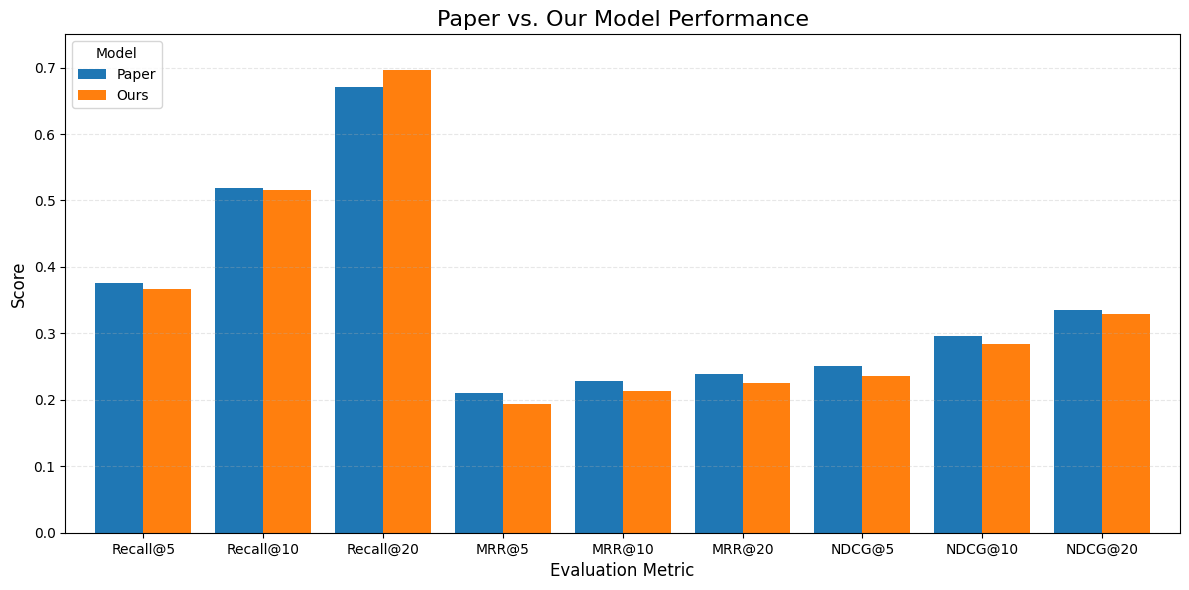

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Metric": [
        "Recall@5", "Recall@10", "Recall@20",
        "MRR@5", "MRR@10", "MRR@20",
        "NDCG@5", "NDCG@10", "NDCG@20"
    ],
    "Paper": [
        0.3753, 0.5186, 0.6713,
        0.2104, 0.2290, 0.2395,
        0.2509, 0.2967, 0.3352
    ],
    "Ours": [
        0.3669, 0.5154, 0.6957,
        0.1936, 0.2132, 0.2258,
        0.2363, 0.2841, 0.3297
    ]
}

df = pd.DataFrame(data)

ax = df.plot(
    x="Metric",
    y=["Paper", "Ours"],
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title("Paper vs. Our Model Performance", fontsize=16)
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.ylim(0, 0.75)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(
    title="Model",
    loc="upper left"
)

plt.tight_layout()

# Save as high-quality image
plt.savefig(
    "paper_vs_ours.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

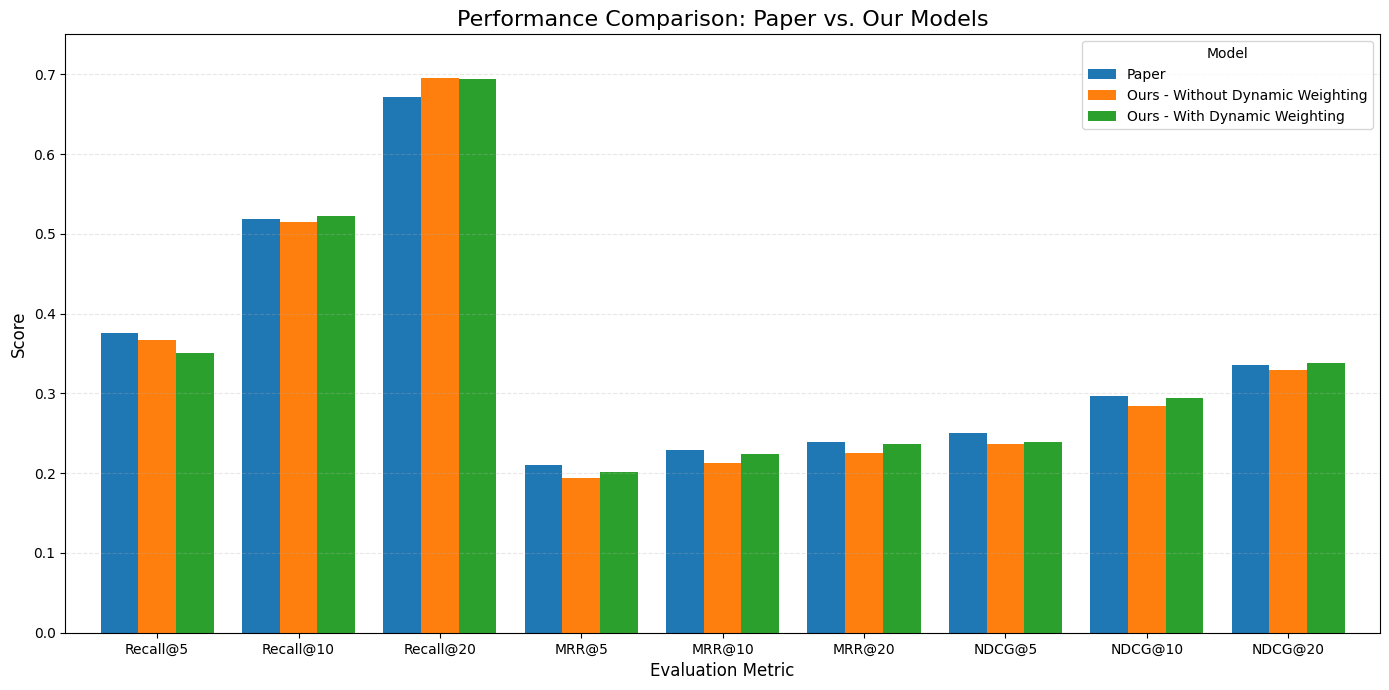

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Metric": [
        "Recall@5", "Recall@10", "Recall@20",
        "MRR@5", "MRR@10", "MRR@20",
        "NDCG@5", "NDCG@10", "NDCG@20"
    ],

    "Paper": [
        0.3753, 0.5186, 0.6713,
        0.2104, 0.2290, 0.2395,
        0.2509, 0.2967, 0.3352
    ],

    "Ours - Without Dynamic Weighting": [
        0.3669, 0.5154, 0.6957,
        0.1936, 0.2132, 0.2258,
        0.2363, 0.2841, 0.3297
    ],

    "Ours - With Dynamic Weighting": [
        0.3510, 0.5228, 0.6946,
        0.2017, 0.2245, 0.2365,
        0.2385, 0.2940, 0.3375
    ]
}

df = pd.DataFrame(data)

ax = df.plot(
    x="Metric",
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

plt.title(
    "Performance Comparison: Paper vs. Our Models",
    fontsize=16
)

plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.xticks(rotation=0)
plt.ylim(0, 0.75)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    title="Model",
    fontsize=10
)

plt.tight_layout()

# Save high-quality image
plt.savefig(
    "paper_vs_dynamic_weighting.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

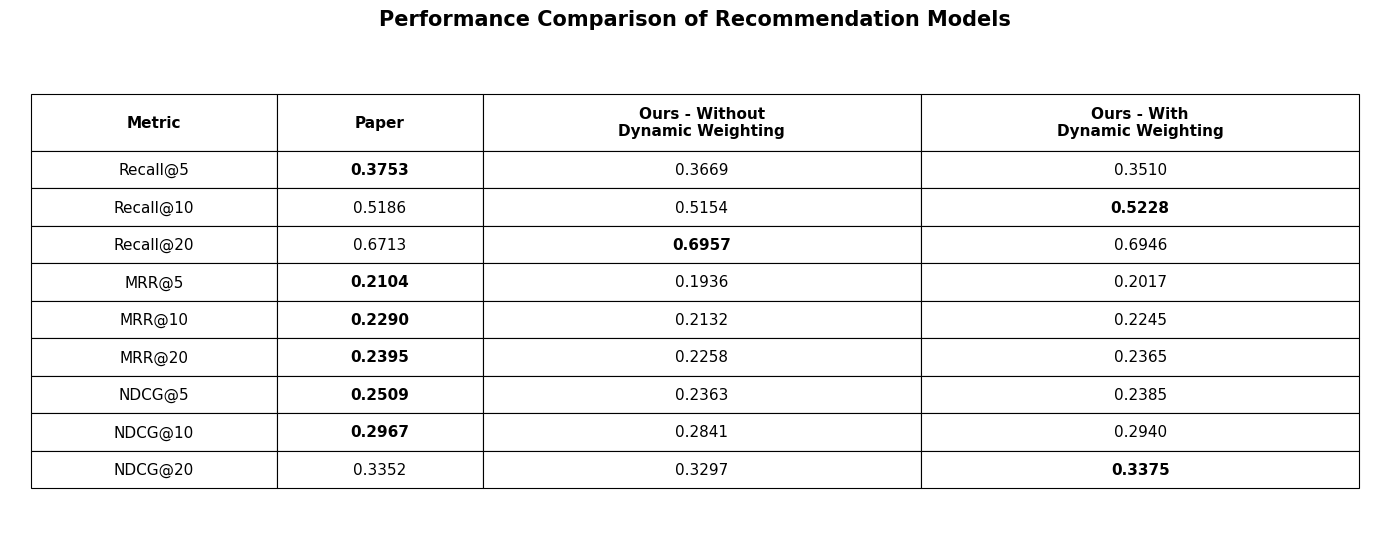

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "Metric": [
        "Recall@5", "Recall@10", "Recall@20",
        "MRR@5", "MRR@10", "MRR@20",
        "NDCG@5", "NDCG@10", "NDCG@20"
    ],
    "Paper": [
        0.3753, 0.5186, 0.6713,
        0.2104, 0.2290, 0.2395,
        0.2509, 0.2967, 0.3352
    ],
    "Ours - Without Dynamic Weighting": [
        0.3669, 0.5154, 0.6957,
        0.1936, 0.2132, 0.2258,
        0.2363, 0.2841, 0.3297
    ],
    "Ours - With Dynamic Weighting": [
        0.3510, 0.5228, 0.6946,
        0.2017, 0.2245, 0.2365,
        0.2385, 0.2940, 0.3375
    ]
}

df = pd.DataFrame(data)

# Create figure
fig, ax = plt.subplots(figsize=(14, 5.5))

ax.axis("off")

# Prepare table
table_data = []

for _, row in df.iterrows():
    values = [
        row["Metric"],
        f'{row["Paper"]:.4f}',
        f'{row["Ours - Without Dynamic Weighting"]:.4f}',
        f'{row["Ours - With Dynamic Weighting"]:.4f}'
    ]
    table_data.append(values)

columns = [
    "Metric",
    "Paper",
    "Ours - Without\nDynamic Weighting",
    "Ours - With\nDynamic Weighting"
]

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.18, 0.15, 0.32, 0.32]
)

# Font and size
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.0)

# Find best value in each row and make it bold
for i in range(len(df)):
    values = [
        df.iloc[i]["Paper"],
        df.iloc[i]["Ours - Without Dynamic Weighting"],
        df.iloc[i]["Ours - With Dynamic Weighting"]
    ]

    best_index = values.index(max(values))

    # +1 because column 0 is Metric
    cell = table[(i + 1, best_index + 1)]
    cell.get_text().set_weight("bold")

# Header formatting
for j in range(len(columns)):
    cell = table[(0, j)]
    cell.get_text().set_weight("bold")
    cell.set_height(0.12)

# Cell formatting
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0.8)

# Title
plt.title(
    "Performance Comparison of Recommendation Models",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

# Save high-resolution image
plt.savefig(
    "performance_comparison_table.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

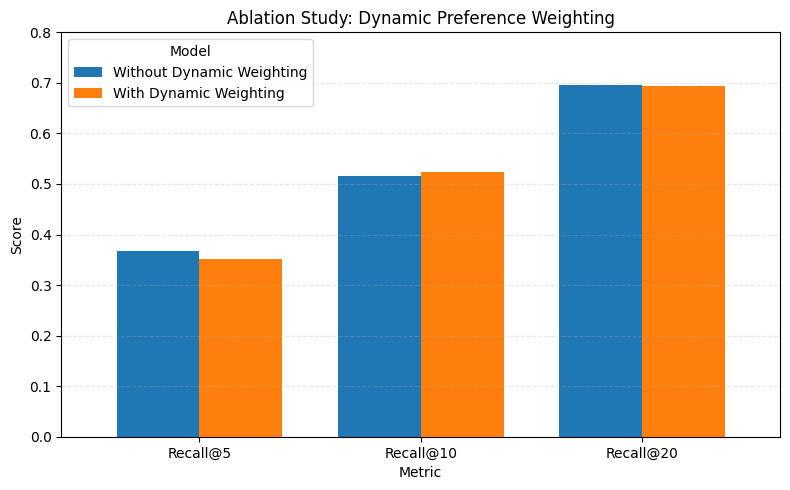

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Metric": ["Recall@5", "Recall@10", "Recall@20"],
    "Without Dynamic Weighting": [0.3669, 0.5154, 0.6957],
    "With Dynamic Weighting": [0.3510, 0.5228, 0.6946]
}

df = pd.DataFrame(data)

ax = df.plot(
    x="Metric",
    kind="bar",
    figsize=(8, 5),
    width=0.75
)

plt.title("Ablation Study: Dynamic Preference Weighting")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 0.8)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Model")

plt.tight_layout()

plt.savefig(
    "ablation_dynamic_weighting_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

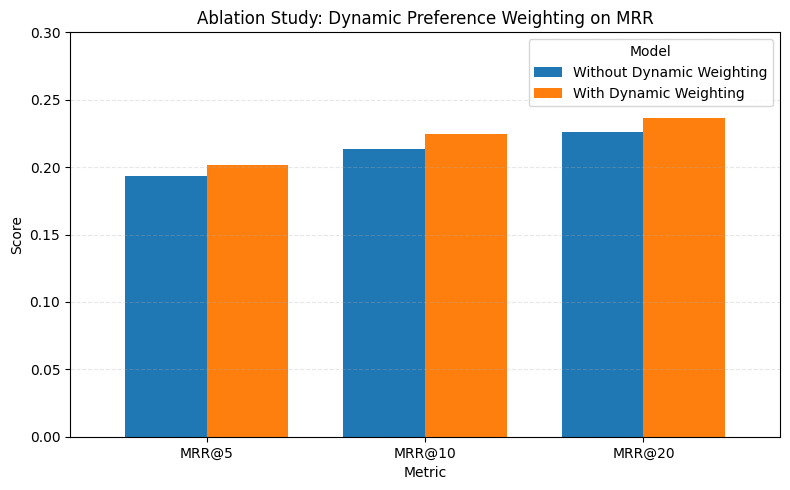

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Metric": ["MRR@5", "MRR@10", "MRR@20"],
    "Without Dynamic Weighting": [
        0.1936, 0.2132, 0.2258
    ],
    "With Dynamic Weighting": [
        0.2017, 0.2245, 0.2365
    ]
}

df = pd.DataFrame(data)

ax = df.plot(
    x="Metric",
    kind="bar",
    figsize=(8, 5),
    width=0.75
)

plt.title("Ablation Study: Dynamic Preference Weighting on MRR")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 0.30)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Model")

plt.tight_layout()

plt.savefig(
    "ablation_dynamic_weighting_mrr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

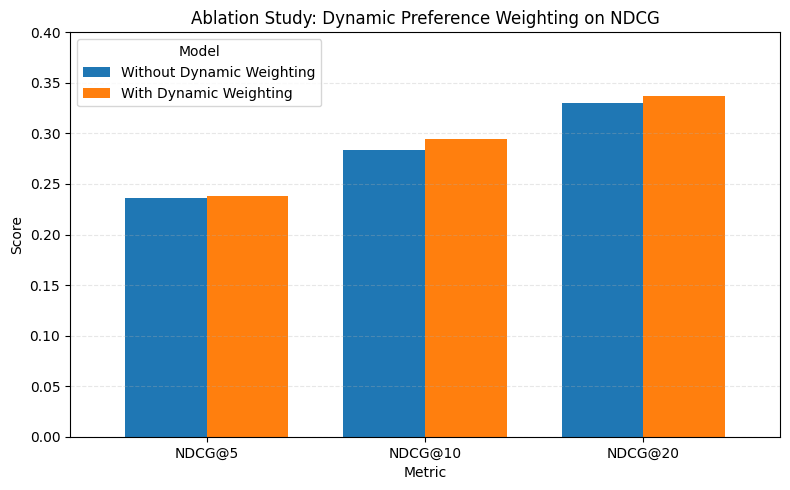

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Metric": ["NDCG@5", "NDCG@10", "NDCG@20"],
    "Without Dynamic Weighting": [
        0.2363, 0.2841, 0.3297
    ],
    "With Dynamic Weighting": [
        0.2385, 0.2940, 0.3375
    ]
}

df = pd.DataFrame(data)

ax = df.plot(
    x="Metric",
    kind="bar",
    figsize=(8, 5),
    width=0.75
)

plt.title("Ablation Study: Dynamic Preference Weighting on NDCG")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 0.40)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Model")

plt.tight_layout()

plt.savefig(
    "ablation_dynamic_weighting_ndcg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

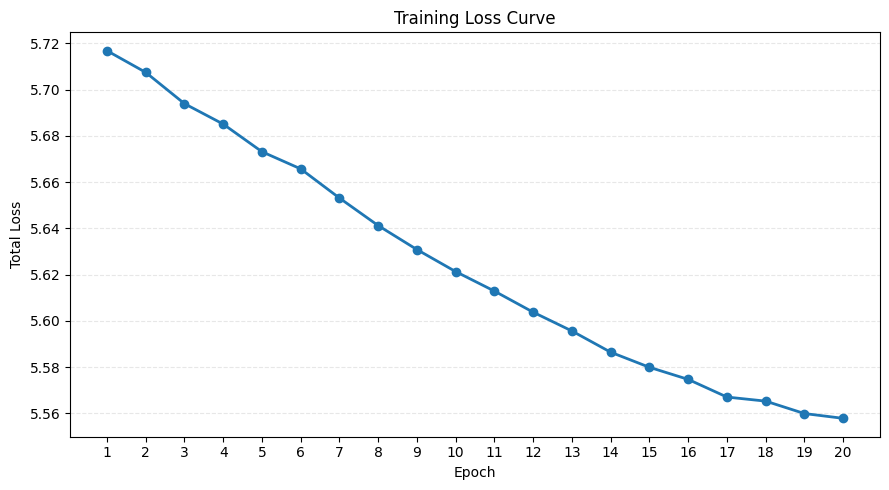

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Epoch": list(range(1, 21)),
    "Total Loss": [
        5.71678, 5.70742, 5.69389, 5.68506, 5.67312,
        5.66570, 5.65310, 5.64119, 5.63082, 5.62130,
        5.61287, 5.60375, 5.59563, 5.58646, 5.57994,
        5.57471, 5.56708, 5.56532, 5.55995, 5.55788
    ]
}

df = pd.DataFrame(data)

plt.figure(figsize=(9, 5))

plt.plot(
    df["Epoch"],
    df["Total Loss"],
    marker="o",
    linewidth=2
)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.xticks(range(1, 21))
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "training_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

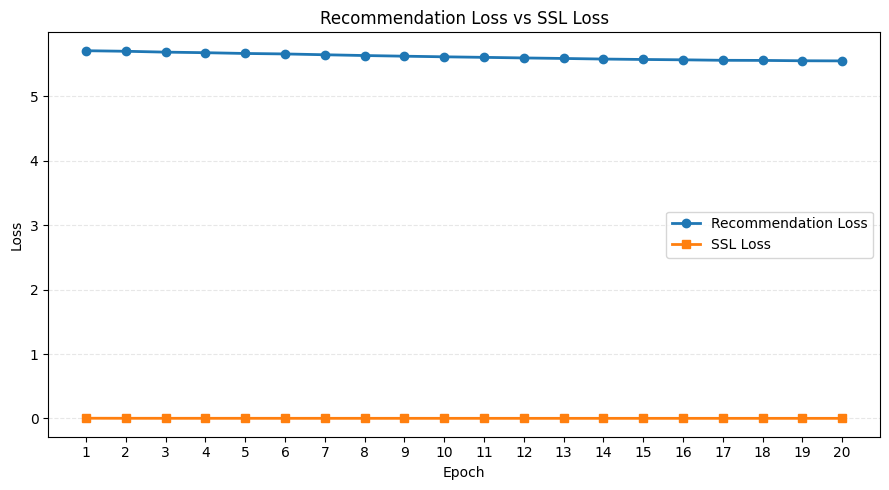

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Epoch": list(range(1, 21)),

    "Recommendation Loss": [
        5.70995, 5.70139, 5.68793, 5.67916, 5.66716,
        5.65986, 5.64719, 5.63522, 5.62485, 5.61529,
        5.60688, 5.59775, 5.58965, 5.58048, 5.57392,
        5.56870, 5.56107, 5.55933, 5.55393, 5.55184
    ],

    "SSL Loss": [
        0.00332, 0.00242, 0.00221, 0.00214, 0.00212,
        0.00193, 0.00190, 0.00185, 0.00182, 0.00173,
        0.00176, 0.00166, 0.00162, 0.00161, 0.00164,
        0.00162, 0.00163, 0.00162, 0.00160, 0.00161
    ]
}

df = pd.DataFrame(data)

plt.figure(figsize=(9, 5))

plt.plot(
    df["Epoch"],
    df["Recommendation Loss"],
    marker="o",
    linewidth=2,
    label="Recommendation Loss"
)

plt.plot(
    df["Epoch"],
    df["SSL Loss"],
    marker="s",
    linewidth=2,
    label="SSL Loss"
)

plt.title("Recommendation Loss vs SSL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, 21))
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "recommendation_vs_ssl_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

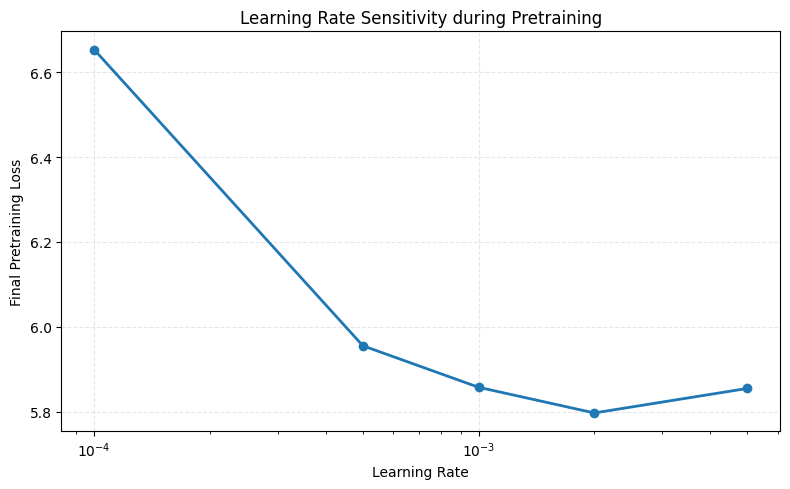

In [1]:
import matplotlib.pyplot as plt

learning_rates = [1e-4, 5e-4, 1e-3, 2e-3, 5e-3]

final_losses = [
    6.65398,
    5.95532,
    5.85731,
    5.79678,
    5.85461
]

plt.figure(figsize=(8, 5))

plt.plot(
    learning_rates,
    final_losses,
    marker="o",
    linewidth=2
)

plt.xscale("log")

plt.xlabel("Learning Rate")
plt.ylabel("Final Pretraining Loss")
plt.title("Learning Rate Sensitivity during Pretraining")

plt.grid(axis="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "pretraining_learning_rate_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

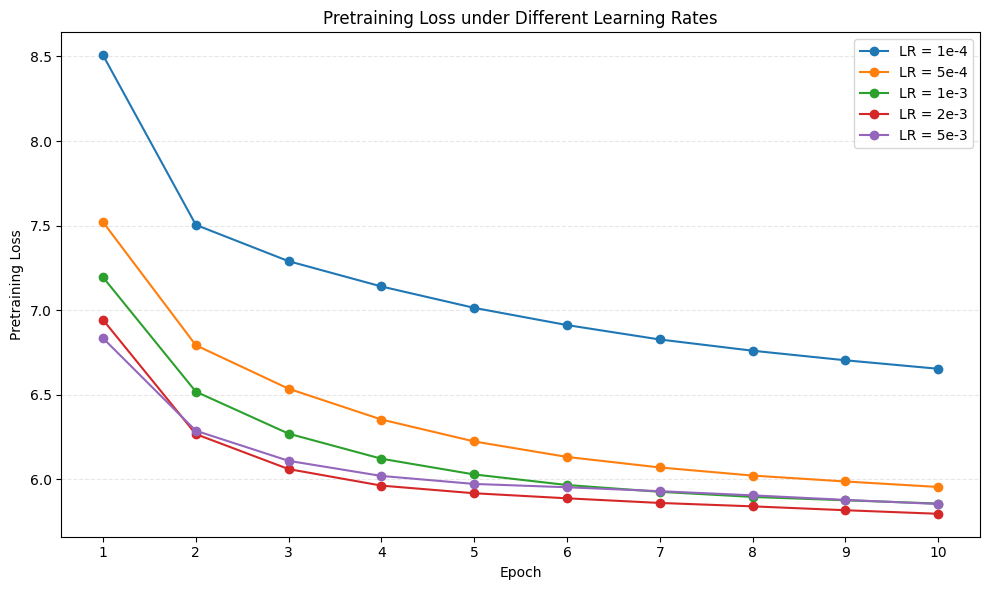

In [11]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))
# epochs1 = list(range(1, 12))


loss_1e4 = [
    8.50726, 7.50466, 7.28994, 7.14046, 7.01402,
    6.91232, 6.82712, 6.76074, 6.70422, 6.65398
]

loss_5e4 = [
    7.52091, 6.79314, 6.53601, 6.35402, 6.22435,
    6.13287, 6.07062, 6.02269, 5.98777, 5.95532
]

loss_1e3 = [
    7.19484, 6.51869, 6.27040, 6.12227, 6.02928,
    5.96697, 5.92672, 5.89652, 5.87663, 5.85731
]

loss_2e3 = [
    6.94310, 6.26781, 6.06102, 5.96333, 5.91818,
    5.88834, 5.86086, 5.84076, 5.81785, 5.79678
]

loss_5e3 = [
    6.83459, 6.28779, 6.10978, 6.02049, 5.97324,
    5.95365, 5.93049, 5.90580, 5.87896, 5.85461
]

plt.figure(figsize=(10, 6))

plt.plot(epochs, loss_1e4, marker="o", label="LR = 1e-4")
plt.plot(epochs, loss_5e4, marker="o", label="LR = 5e-4")
plt.plot(epochs, loss_1e3, marker="o", label="LR = 1e-3")
plt.plot(epochs, loss_2e3, marker="o", label="LR = 2e-3")
# plt.plot(epochs1, loss_5e3, marker="o", label="LR = 5e-3")
plt.plot(epochs, loss_5e3, marker="o", label="LR = 5e-3")


plt.xlabel("Epoch")
plt.ylabel("Pretraining Loss")
plt.title("Pretraining Loss under Different Learning Rates")

plt.xticks(epochs)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "pretraining_loss_learning_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()